# Fetching Raw Data

In [1]:
import os
import zipfile

train_zip_path = '/kaggle/input/competitions/dogs-vs-cats/train.zip'
test_zip_path = '/kaggle/input/competitions/dogs-vs-cats/test1.zip'
working_dir = '/kaggle/working/'

# Extract train.zip
print("Extracting training images...")
with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
    zip_ref.extractall(working_dir)

# Extract test1.zip
print("Extracting testing images...")
with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(working_dir)

print("Extraction complete!")

Extracting training images...
Extracting testing images...
Extraction complete!


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
#To check whether GPU is available or not
print("Positive") if torch.accelerator.is_available() else print("Negative")

Positive


In [4]:
#Example showing tensor moved to GPU
# if torch.accelerator.is_available():
#     tensor = tensor.to(torch.accelerator.current_accelerator())

# Data Processing and Loading

In [5]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2

transform = v2.Compose([
    v2.Resize((128,128)),
    v2.ToImage(),    #Converts image to tensor
    v2.ToDtype(torch.float32, scale=True),    #Scales the tensor
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))    #Normalizes the tensor
])

In [6]:
# Creating a class (literally the class acts like a format in which the dataset of images is formatted to be processed subsequently)
# Custom Dataset

class KaggleCatsAndDogs(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.filenames = os.listdir(root_dir)    #Create list of images (only the filenames)

    def __len__(self):
        return len(self.filenames)    #To get the number of datas

    def __getitem__(self, idx):
        img_name = self.filenames[idx]
        img_path = os.path.join(self.root_dir, img_name)

        image = Image.open(img_path)

        category = img_name.split('.')[0]
        label = 1 if category == "dog" else 0    #Categorize the image into dogs and cats

        if self.transform:    #To check whether transform!=None
            image = self.transform(image)    #Converts the PIL image as per the transform pipeline

        return image, torch.tensor(label, dtype=torch.long)    #Returns the tranformed image and the labels is converted to tensor and exported

In [7]:
from torch.utils.data import random_split

data_dir = '/kaggle/working/train/'
full_trainset = KaggleCatsAndDogs(data_dir, transform)    #this is an object

train_size = int(0.8 * len(full_trainset))    #Training Set = 80%
val_size = len(full_trainset) - train_size
trainset, valset = random_split(full_trainset, [train_size, val_size])

train_loader = DataLoader(trainset, 
                          batch_size=32, 
                          shuffle=True, 
                          num_workers=4,          # Uses multi-threading on CPU to load images in parallel
                          pin_memory=True         # Speeds up tensor transfer from CPU memory to GPU memory)
                         )
print(f"Successfully loaded {len(trainset)} images into PyTorch")

val_loader = DataLoader(valset, 
                          batch_size=32, 
                          shuffle=True, 
                          num_workers=4,          # Uses multi-threading on CPU to load images in parallel
                          pin_memory=True         # Speeds up tensor transfer from CPU memory to GPU memory)
                         )
print(f"Successfully loaded {len(valset)} images into PyTorch")

Successfully loaded 20000 images into PyTorch
Successfully loaded 5000 images into PyTorch


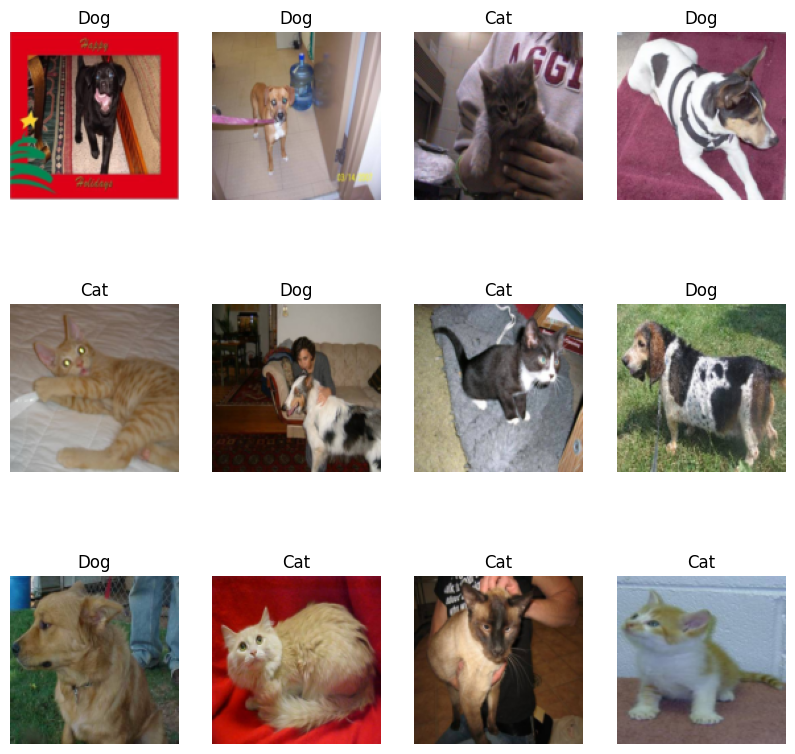

In [8]:
#Visualize the dataset

import matplotlib.pyplot as plt
labels_map = {
    0: "Cat",
    1: "Dog",
}
figure = plt.figure(figsize=(10, 10))
cols, rows = 4, 3

for i in range(1, cols*rows+1):
    sample_idx = torch.randint(len(trainset), size=(1,)).item()
    img, label = trainset[sample_idx]
    
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label.item()])
    plt.axis("off")

    if trainset.dataset.transform is not None:
        # UN-NORMALIZE: Reverse the (x - 0.5) / 0.5 math
        img = (img * 0.5) + 0.5    # Un-normalize image otherwise image shown will be underexposed due to the -ve values changed to 0
        
        # Fix the dimensions for Matplotlib (Color, Height, Width -> Height, Width, Color)
        img_plot = img.permute(1, 2, 0)
        
        # Display the image without the grayscale enforcer
        plt.imshow(img_plot)
        
    else:
        plt.imshow(img)
    
plt.show()

# Building the CNN

In [9]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [10]:
class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()    #Set-up nn.Module

        self.conv_layers = nn.Sequential(
            #Layer 1    128x128 -> 64x64
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Layer 2    64x64 -> 32x32
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Layer 3    32x32 -> 16x16
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Dimension of image = [128 channels, 16 height, 16 width]
        )

        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=128*16*16, out_features=256),
            nn.ReLU(),
            nn.Linear(256, 2)    # 2 output classes
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layer(x)
        return x

In [11]:
model = CatDogCNN().to(device)

# Enable Multi-GPU if more than 1 GPU is available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

model

Using 2 GPUs!


DataParallel(
  (module): CatDogCNN(
    (conv_layers): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (fc_layer): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=32768, out_features=256, bias=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=2, bias=True)
    )
  )
)

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [13]:
epochs = 30

model.train()

for epoch in range(epochs):
    epoch_training_loss = 0.0

    for images, labels in train_loader:  #Iterate thru each batch
        # Move batches to GPU if available
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = model(images)  #FP
        loss = criterion(outputs, labels)  #Loss fnx
        loss.backward()     #BP
        optimizer.step()    #Update params

        epoch_training_loss += loss.item()

    avg_loss = epoch_training_loss/len(train_loader)

    print(f"Epoch: {epoch+1}/{epochs} \tLoss: {avg_loss:.6f}")

Epoch: 1/30 	Loss: 0.595735
Epoch: 2/30 	Loss: 0.453677
Epoch: 3/30 	Loss: 0.375542
Epoch: 4/30 	Loss: 0.290206
Epoch: 5/30 	Loss: 0.199519
Epoch: 6/30 	Loss: 0.104964
Epoch: 7/30 	Loss: 0.057238
Epoch: 8/30 	Loss: 0.037952
Epoch: 9/30 	Loss: 0.036285
Epoch: 10/30 	Loss: 0.032668
Epoch: 11/30 	Loss: 0.022986
Epoch: 12/30 	Loss: 0.027172
Epoch: 13/30 	Loss: 0.028298
Epoch: 14/30 	Loss: 0.012214
Epoch: 15/30 	Loss: 0.013836
Epoch: 16/30 	Loss: 0.025024
Epoch: 17/30 	Loss: 0.025622
Epoch: 18/30 	Loss: 0.013900
Epoch: 19/30 	Loss: 0.010309
Epoch: 20/30 	Loss: 0.014244
Epoch: 21/30 	Loss: 0.025690
Epoch: 22/30 	Loss: 0.022297
Epoch: 23/30 	Loss: 0.011397
Epoch: 24/30 	Loss: 0.012761
Epoch: 25/30 	Loss: 0.008817
Epoch: 26/30 	Loss: 0.004315
Epoch: 27/30 	Loss: 0.032310
Epoch: 28/30 	Loss: 0.007444
Epoch: 29/30 	Loss: 0.017182
Epoch: 30/30 	Loss: 0.009023


# Evaluate the CNN

In [14]:
correct_labels = 0
total_labels = 0

all_preds, all_labels = [], []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.shape[0]

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
print(f"Accuracy Score: {correct_labels/total_labels*100}%")
print()
print(classification_report(all_labels, all_preds, target_names=["Cat", "Dog"]))
print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))

Accuracy Score: 81.76%

              precision    recall  f1-score   support

         Cat       0.82      0.80      0.81      2460
         Dog       0.81      0.83      0.82      2540

    accuracy                           0.82      5000
   macro avg       0.82      0.82      0.82      5000
weighted avg       0.82      0.82      0.82      5000

Confusion Matrix:
 [[1975  485]
 [ 427 2113]]
